# Week 2 - Exploratory Data Analysis and Plotting


In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This prevents pandas from showing weird warnings
pd.options.mode.chained_assignment = None

db_path = "data.duckdb"
schema = "data.attendance"

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")
conn.execute(f"USE {schema}");


Let's pick up where we left from on Wednesday - I will take the query from the data cleaning notebook and paste it in here. This is the only time we'll be using duckdb in this lecture.

In [ ]:
df = conn.sql(
"""
    WITH attendance AS (
        SELECT
            report_period,
            school_code,
            student_class,
            subject_code,
            electronic_diary,
            FIRST(student_count_diary) student_count_diary,
            SUM(excused_lessons_illness::int) excused_lessons_illness,
            SUM(excused_lessons_other::int) excused_lessons_other,
            SUM(unexcused_lessons::int) unexcused_lessons
        FROM attendance
        WHERE division_code IS NULL
        GROUP BY all
    ),
        school AS (
        SELECT 
            school_code, 
            school_name, 
            municipality_name
        FROM school
        WHERE division_code IS NULL
    ),
        subject AS (
        SELECT
            electronic_diary,
            subject_code,
            subject_name_en,
        FROM subject
    )
    SELECT
        school.school_name,
        school.school_code,
        school.municipality_name,
        attendance.student_class as student_class,
        attendance.report_period as report_period,
        subject.subject_name_en,
        FIRST(attendance.student_count_diary) AS student_count,
        SUM(attendance.excused_lessons_illness) AS excused_lessons_illness,
        SUM(attendance.excused_lessons_other) AS excused_lessons_other,
        SUM(attendance.unexcused_lessons) AS unexcused_lessons
    FROM attendance
    JOIN school ON attendance.school_code = school.school_code
    JOIN subject ON attendance.subject_code = subject.subject_code
        AND attendance.electronic_diary = subject.electronic_diary
    GROUP BY all
""").df()


In [3]:
df.dtypes

school_name                        object
school_code                         int64
municipality_name                  object
student_class                       int64
report_period              datetime64[us]
subject_name_en                    object
student_count                       int64
excused_lessons_illness           float64
excused_lessons_other             float64
unexcused_lessons                 float64
dtype: object

There's one weird thing I noticed about the attendance dataset.


In [4]:
df[
    (df["school_name"].str.contains("Vilniaus Užupio"))
    & (df["student_class"] == 10)
    & (df["report_period"] == "2021-01-01")
].head(5)

,school_name,school_code,municipality_name,student_class,report_period,subject_name_en,student_count,excused_lessons_illness,excused_lessons_other,unexcused_lessons
614165,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,10,2021-01-01,Lithuanian language and literature,155,26.0,11.0,32.0
656929,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,10,2021-01-01,"Foreign language (first, English)",155,9.0,7.0,33.0
1653610,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,10,2021-01-01,"Foreign language (second, Russian)",155,4.0,0.0,11.0
1729906,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,10,2021-01-01,Dance,155,0.0,0.0,0.0
1886548,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,10,2021-01-01,Civic foundations,155,3.0,0.0,0.0


Above I filtered on every dimension except `period` and `subject_name_en`. What we see is that different subjects have exactly the same student count. In other words, the student count is on the class, and not the subject, level. This is sad news because this renders the dataset way less useful. For instance, we cannot compare e.g. `excused_lessons_illness / student_count` between different subjects, because this ratio might differ due to several reasons:
- different number of students that take this subject.
- different number of students have excused lessons.

Therefore, the rest of analysis uses just Mathematics as the subject.


In [5]:
df = df[(df["subject_name_en"] == "Mathematics") & (df["student_class"] == 12)]

There's another thing - I know I will be making a lot of plots that compare attendance numbers across time. However, the set of schools in the dataset is not uniform across time.

<Axes: xlabel='report_period'>

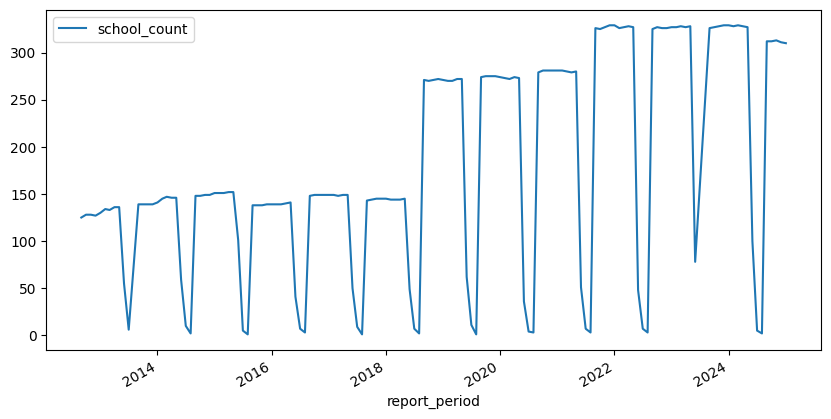

In [6]:
df.groupby("report_period").agg(school_count=("school_name", "nunique")).plot.line(
    y="school_count", figsize=(10, 5)
)

Now there is one issue here - we will be comparing attendance numbers between years, but we won't be comparing apples to apples. Imagine we're comparing attendance between 2021 and 2022 and see big differences - are these differences there because something changed in the environment (quarantine, flu season, good weather), or because a bunch of new schools started using electronic diaries in 2022 and these schools also happen to have different attendance trends?

Overall, there's three things I want to do:
- Filter the dataset to be only for the period 2018-09-01 to 2024-05-31. 2018 September because that's when a bunch of new schools appeared in the dataset, 2024 May because that's when the 2023-2024 school year ended, and for 2024-2025 we don't have a full school year yet.
- We have to make sure that the set of schools is the same across the years.
- Get rid of summer months (nothing happens there)


In [7]:
# Filter on report period
df = df[df["report_period"].between("2018-09-01", "2024-05-31")]


In [9]:
df["month"] = df["report_period"].dt.month


In [11]:
# Get rid of summer months
df["month"] = df["report_period"].dt.month
df = df[~df["month"].isin([6, 7, 8])]

In [53]:
# Make sure the set of schools is the same across the years

# First, count how many report periods each school has
schools = df.groupby("school_name").agg(
    report_period_count=("report_period", "nunique")
)

# Then, filter on the schools that have data for all 6 school years (9 months each year)
schools = schools[schools["report_period_count"] == 6 * 9]
schools["report_period_count"]


school_name
Akmenės rajono Papilės Simono Daukanto gimnazija          54
Akmenės rajono Ventos gimnazija                           54
Akmenės rajono jaunimo ir suaugusiųjų švietimo centras    54
Alytaus Adolfo Ramanausko-Vanago gimnazija                54
Alytaus Jotvingių gimnazija                               54
                                                          ..
Šilutės r. Žemaičių Naumiesčio gimnazija                  54
Širvintų Lauryno Stuokos-Gucevičiaus gimnazija            54
Širvintų r. Gelvonų gimnazija                             54
Širvintų r. Musninkų Alfonso Petrulio gimnazija           54
Švenčionių Zigmo Žemaičio gimnazija                       54
Name: report_period_count, Length: 210, dtype: int64

In [54]:
df = df[df["school_name"].isin(schools.index)]

<Axes: xlabel='report_period'>

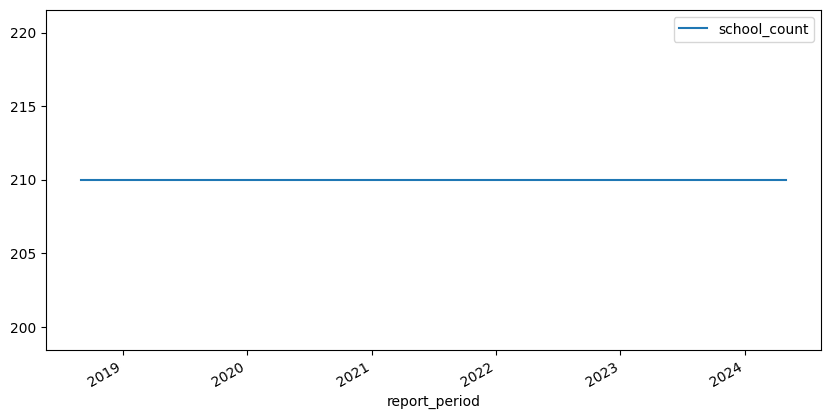

In [55]:
# Let's validate by plotting the number of schools over time
df.groupby("report_period").agg(school_count=("school_name", "nunique")).plot.line(
    y="school_count", figsize=(10, 5)
)


There's one last thing I want to do - we're analysing school information, therefore we need a `school_year` column - a column whose value only changes once `report_period` reaches September.

In [56]:
df["report_period"].dt.to_period("M").dt.to_timestamp()


490       2020-02-01
702       2022-11-01
1071      2023-12-01
1360      2023-10-01
1758      2021-03-01
             ...    
4910604   2024-01-01
4911380   2018-12-01
4911983   2022-04-01
4912400   2023-05-01
4912581   2022-03-01
Name: report_period, Length: 11340, dtype: datetime64[ns]

In [57]:
df["school_year"] = df["report_period"].dt.year - (
    df["report_period"].dt.month <= 5
).astype(int)


In [60]:
df[["report_period", "school_year"]].sample(5)

,report_period,school_year
4604987,2020-02-01,2019
1995091,2021-10-01,2021
4841694,2020-02-01,2019
2410760,2022-01-01,2021
1747661,2021-01-01,2020


Notice above how for report periods in spring I get a school year that is one year lower - which is what we want.

Ok, let's begin our analysis now. It's important to keep in mind that our analysis is specifically about:
- 12th grade
- mathematics
- school year (excl. summer months)
- the 210 schools that were in the dataset between school years 2018 to 2022


Now I'm thinking in advance what kind of plots I will want to make. I will want to make plots of the `student_count`, `excused_lessons_illness`, and so on columns, but in their raw form they're less interesting, instead it would be better to look at their ratios:
- `excused_lessons_illness` / `student_count`
- `excused_lessons_other` / `student_count`
- `unexcused_lessons_other` / `student_count`
- (sum of all three columns) / `student_count`

Let's create these columns now.


In [48]:
df["excused_illness_per_student"] = df["excused_lessons_illness"] / df["student_count"]
df["excused_other_per_student"] = df["excused_lessons_other"] / df["student_count"]
df["unexcused_per_student"] = df["unexcused_lessons"] / df["student_count"]
df["total_missed"] = (
    df["excused_lessons_illness"]
    + df["excused_lessons_other"]
    + df["unexcused_lessons"]
)
df["total_missed_per_student"] = df["total_missed"] / df["student_count"]

df.sample(5)

,school_name,school_code,municipality_name,student_class,report_period,subject_name_en,student_count,excused_lessons_illness,excused_lessons_other,unexcused_lessons,month,school_year,excused_illness_per_student,excused_other_per_student,unexcused_per_student,total_missed,total_missed_per_student
4498046,Varėnos „Ąžuolo“ gimnazija,190108756,Varėnos r. sav.,12,2024-02-01,Mathematics,98,155.0,72.0,0.0,2,2023,1.581633,0.734694,0.000000,227.0,2.316327
3320078,Kaišiadorių Algirdo Brazausko gimnazija,190596280,Kaišiadorių r. sav.,12,2022-12-01,Mathematics,97,149.0,30.0,10.0,12,2022,1.536082,0.309278,0.103093,189.0,1.948454
3273063,Klaipėdos Vydūno gimnazija,190910382,Klaipėdos m. sav.,12,2018-11-01,Mathematics,52,28.0,29.0,0.0,11,2018,0.538462,0.557692,0.000000,57.0,1.096154
375023,Trakų Vytauto Didžiojo gimnazija,190667368,Trakų r. sav.,12,2022-05-01,Mathematics,72,47.0,56.0,12.0,5,2021,0.652778,0.777778,0.166667,115.0,1.597222
1783732,Raseinių r. Viduklės Simono Stanevičiaus gimna...,190106933,Raseinių r. sav.,12,2023-03-01,Mathematics,21,25.0,0.0,0.0,3,2022,1.190476,0.000000,0.000000,25.0,1.190476


## lineplots

Lineplots are for visualizing time series.

Let's begin with something very simple - a single school.


In [49]:
df_uzupis = df[(df["school_name"].str.contains("Vilniaus Užupio"))]  # My school
df_uzupis.sample(5)

,school_name,school_code,municipality_name,student_class,report_period,subject_name_en,student_count,excused_lessons_illness,excused_lessons_other,unexcused_lessons,month,school_year,excused_illness_per_student,excused_other_per_student,unexcused_per_student,total_missed,total_missed_per_student
1079215,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2024-05-01,Mathematics,154,86.0,32.0,169.0,5,2023,0.558442,0.207792,1.097403,287.0,1.863636
1887641,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2023-12-01,Mathematics,155,177.0,15.0,92.0,12,2023,1.141935,0.096774,0.593548,284.0,1.832258
2003900,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2020-04-01,Mathematics,151,16.0,0.0,81.0,4,2019,0.105960,0.000000,0.536424,97.0,0.642384
239018,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2020-09-01,Mathematics,136,49.0,5.0,107.0,9,2020,0.360294,0.036765,0.786765,161.0,1.183824
1424840,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2018-11-01,Mathematics,152,207.0,59.0,92.0,11,2018,1.361842,0.388158,0.605263,358.0,2.355263


<Axes: xlabel='report_period'>

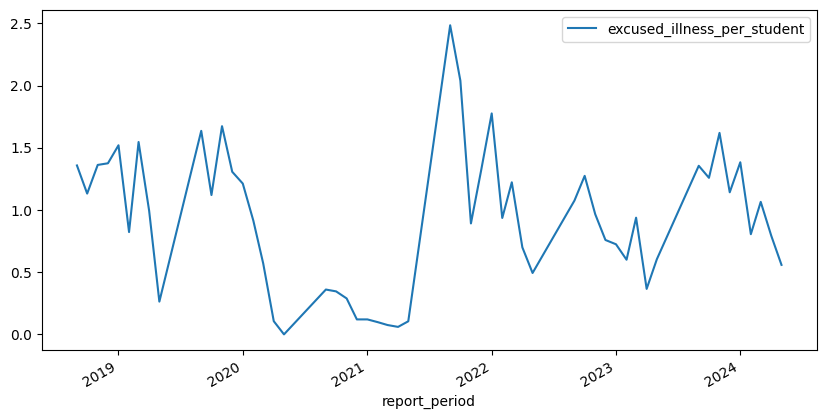

In [50]:
df_uzupis.sort_values(by="report_period").plot.line(
    x="report_period", y="excused_illness_per_student", figsize=(10, 5)
)

<Axes: xlabel='report_period'>

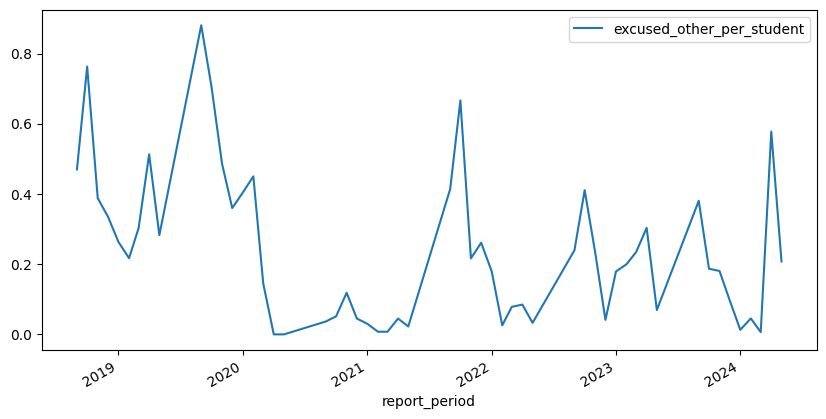

In [51]:
df_uzupis.sort_values(by="report_period").plot.line(
    x="report_period", y="excused_other_per_student", figsize=(10, 5)
)

<Axes: xlabel='report_period'>

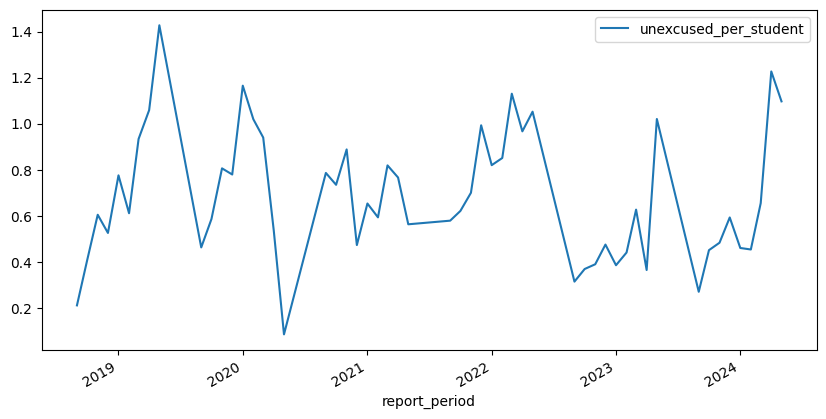

In [52]:
df_uzupis.sort_values(by="report_period").plot.line(
    x="report_period", y="unexcused_per_student", figsize=(10, 5)
)

Is there a more concise way to display the same information, both in terms of code and the number of plots?

<Axes: xlabel='report_period', ylabel='excused_illness_per_student'>

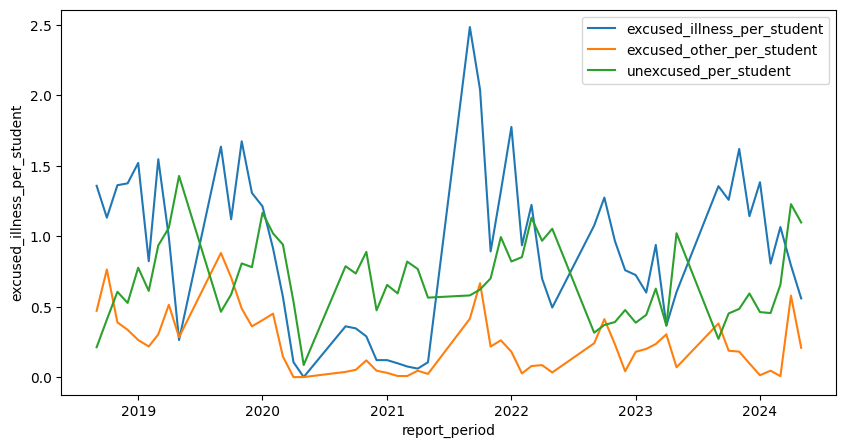

In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_uzupis,
    x="report_period",
    y="excused_illness_per_student",
    label="excused_illness_per_student",
)
sns.lineplot(
    data=df_uzupis,
    x="report_period",
    y="excused_other_per_student",
    label="excused_other_per_student",
)
sns.lineplot(
    data=df_uzupis,
    x="report_period",
    y="unexcused_per_student",
    label="unexcused_per_student",
)

We are repeating ourselves - executing the same line of code except for the name of the column in the dataframe. 

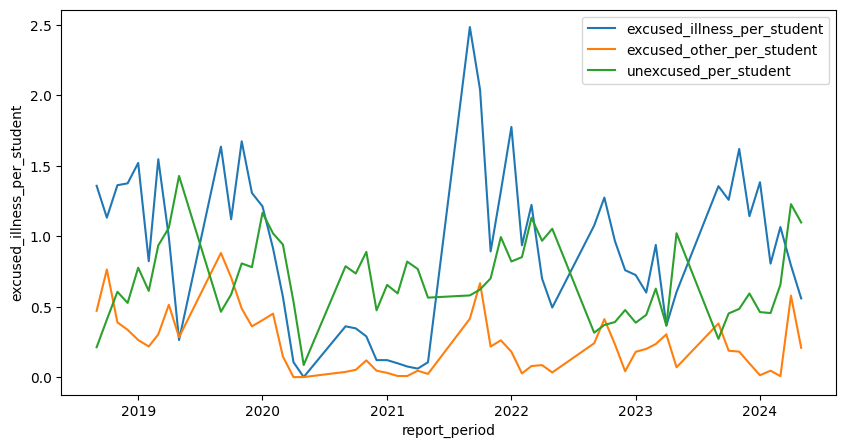

In [24]:
plt.figure(figsize=(10, 5))
columns = [
    "excused_illness_per_student",
    "excused_other_per_student",
    "unexcused_per_student",
]
for column in columns:
    sns.lineplot(
        data=df_uzupis,
        x="report_period",
        y=column,
        label=column,  # linestyle="--"
    )

Lesson one for today - don't repeat yourself. If you're making multiple plots of the same kind while just changing one variable or one column name, use a for loop.

We've reduced the dataset to just the time dimension, now let's add dimensions by keeping more schools in the dataframe.


In [25]:
df_three_schools = df[
    (
        df["school_name"].str.contains("Vilniaus Užupio")
        | df["school_name"].str.contains("Vilniaus Antakalnio")
        | df["school_name"].str.contains("Vilniaus Gabijos")
    )
]
df_three_schools.sample(5)

,school_name,school_code,municipality_name,student_class,report_period,subject_name_en,student_count,excused_lessons_illness,excused_lessons_other,unexcused_lessons,month,school_year,excused_illness_per_student,excused_other_per_student,unexcused_per_student,total_missed,total_missed_per_student
1787910,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2023-05-01,Mathematics,144,87.0,10.0,147.0,5,2022,0.604167,0.069444,1.020833,244.0,1.694444
1355466,Vilniaus Antakalnio gimnazija,302817872,Vilniaus m. sav.,12,2024-05-01,Mathematics,149,161.0,23.0,206.0,5,2023,1.080537,0.154362,1.382550,390.0,2.617450
3679163,Vilniaus Užupio gimnazija,190001124,Vilniaus m. sav.,12,2018-09-01,Mathematics,151,205.0,71.0,32.0,9,2018,1.357616,0.470199,0.211921,308.0,2.039735
3656159,Vilniaus Antakalnio gimnazija,302817872,Vilniaus m. sav.,12,2022-11-01,Mathematics,130,140.0,19.0,132.0,11,2022,1.076923,0.146154,1.015385,291.0,2.238462
1835399,Vilniaus Gabijos gimnazija,190003513,Vilniaus m. sav.,12,2019-10-01,Mathematics,96,124.0,6.0,10.0,10,2019,1.291667,0.062500,0.104167,140.0,1.458333


<Axes: xlabel='report_period', ylabel='excused_illness_per_student'>

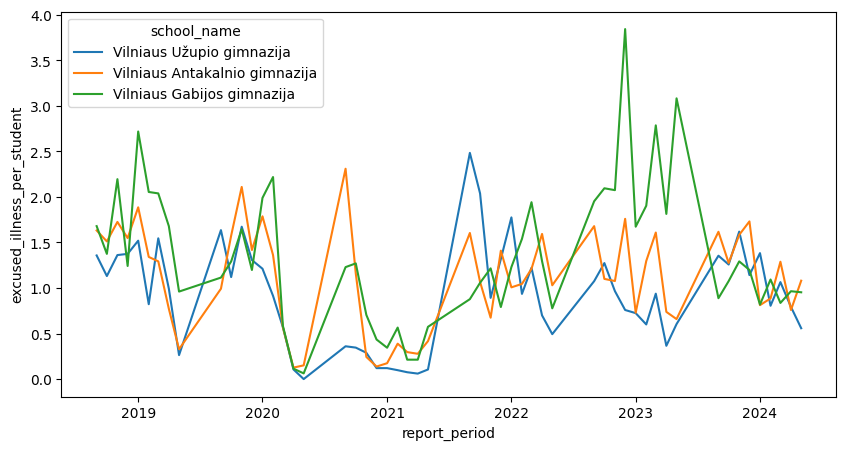

In [61]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_three_schools,
    x="report_period",
    y="excused_illness_per_student",
    hue="school_name",
)

You'll see a repetitive pattern in seaborn - pretty much all plots will have `data`, `x` and `y` parameters (kind of obvious). Also plots for which it makes sense will have the `hue` parameter which allows to create multiple plots on the same canvas for each value of a categorical variable.

## Histograms


In [62]:
df_2019_oct = df[(df["school_year"] == 2019) & (df["month"] == 10)]

<Axes: xlabel='total_missed_per_student', ylabel='Count'>

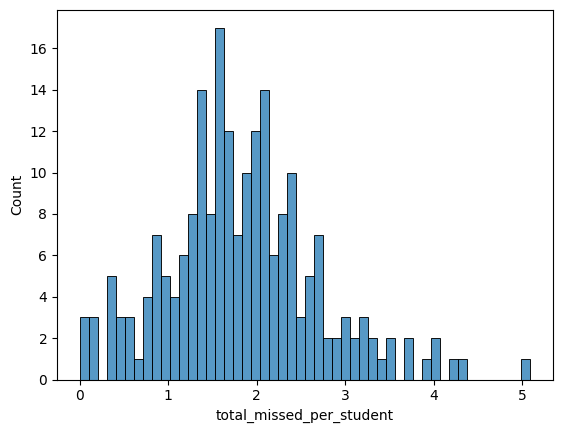

In [70]:
sns.histplot(
    data=df_2019_oct,
    x="total_missed_per_student",
    bins=50,
    # stat="probability",
    # cumulative=True
)

<Axes: xlabel='total_missed_per_student', ylabel='Probability'>

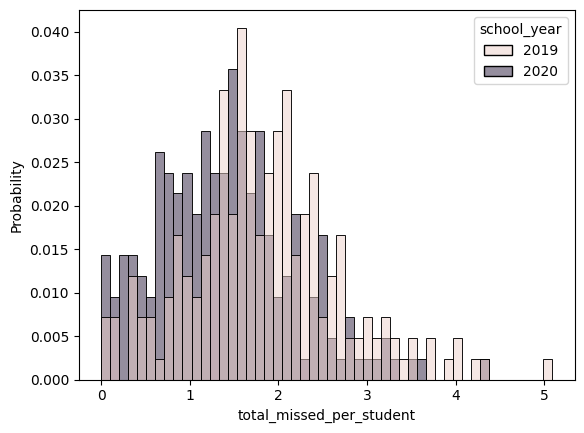

In [64]:
df_2019_2020_oct = df[(df["month"].isin([10])) & (df["school_year"].isin([2019, 2020]))]

sns.histplot(
    data=df_2019_2020_oct,
    x="total_missed_per_student",
    bins=50,
    stat="probability",
    hue="school_year",
)

This plot is difficult to read. Usually if we want to plot two distributions one over another, it's best to use densities.


<Axes: xlabel='total_missed_per_student', ylabel='Density'>

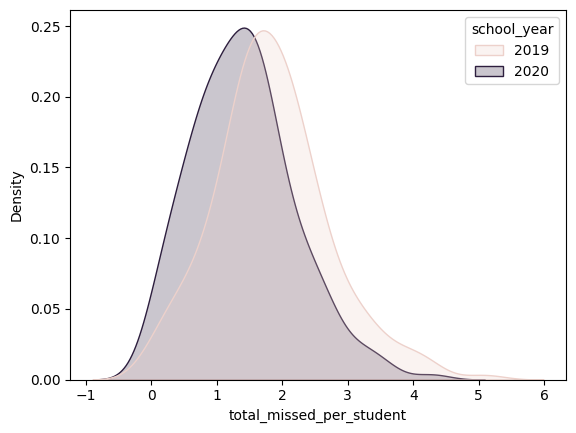

In [65]:
sns.kdeplot(
    data=df_2019_2020_oct,
    x="total_missed_per_student",
    hue="school_year",
    fill=True,
    # palette="Set2", # https://seaborn.pydata.org/tutorial/color_palettes.html
    # common_norm=False
)

<Axes: xlabel='total_missed_per_student', ylabel='Density'>

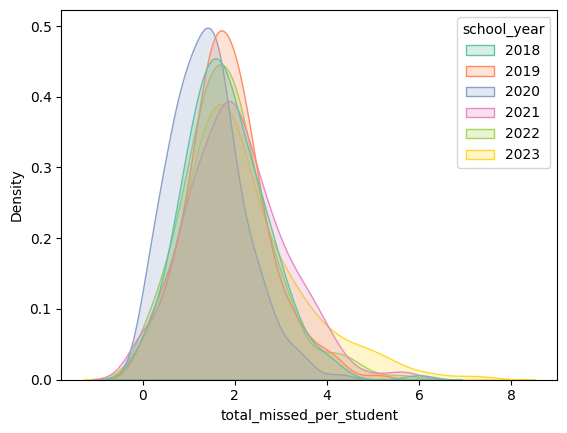

In [66]:
# df_12_all_years = df_12[df_12["year"].isin([2019, 2020, 2021, 2022, 2023, 2024])]
# Better
df_oct_all_years = df[df["month"] == 10]

sns.kdeplot(
    data=df_oct_all_years,
    x="total_missed_per_student",
    hue="school_year",
    fill=True,
    palette="Set2",
    common_norm=False,
)

## Barplots


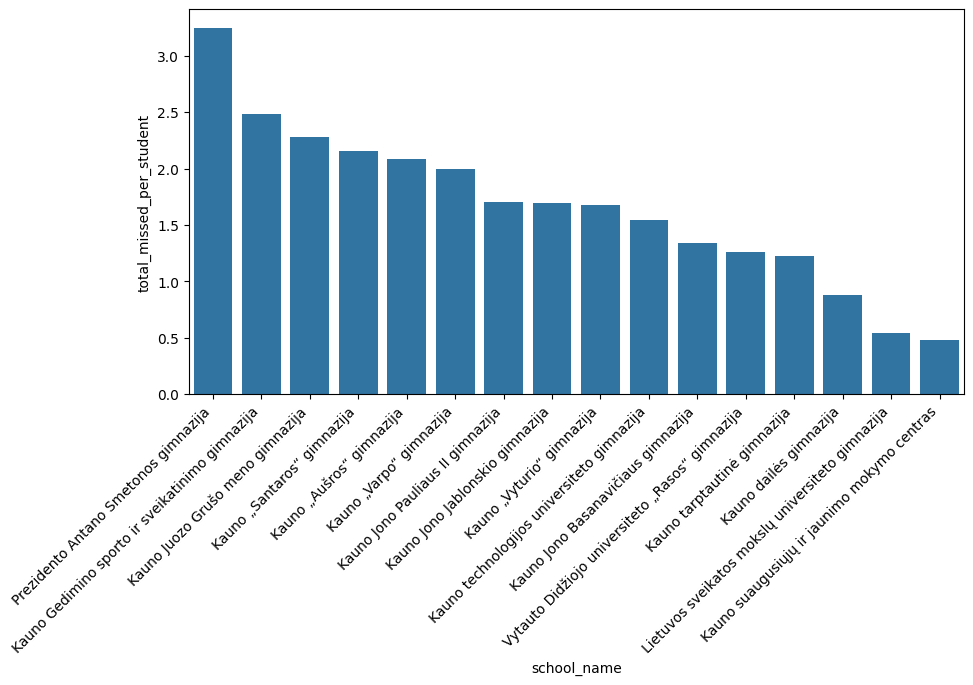

In [32]:
plt.figure(figsize=(10, 5))
df_kaunas_oct_2019 = df[
    (df["municipality_name"] == "Kauno m. sav.")
    & (df["month"] == 10)
    & (df["school_year"] == 2019)
]
ax = sns.barplot(
    data=df_kaunas_oct_2019,
    x="school_name",
    y="total_missed_per_student",
    order=df_kaunas_oct_2019.sort_values(
        by="total_missed_per_student", ascending=False
    )["school_name"],
)
plt.xticks(rotation=45, ha="right");

Personally, I don't often use barplots, because the information can be more easily displayed as a table

## Tables


In [ ]:
df_kaunas_oct_2019[["school_name", "total_missed_per_student"]]


,school_name,total_missed_per_student
102733,Kauno „Vyturio“ gimnazija,1.675676
525311,Prezidento Antano Smetonos gimnazija,3.250000
626790,Vytauto Didžiojo universiteto „Rasos“ gimnazija,1.258621
687095,Kauno Gedimino sporto ir sveikatinimo gimnazija,2.487805
786704,Lietuvos sveikatos mokslų universiteto gimnazija,0.542373
795495,Kauno „Varpo“ gimnazija,2.000000
879517,Kauno dailės gimnazija,0.880952
1739707,Kauno Jono Pauliaus II gimnazija,1.705882
1760431,Kauno technologijos universiteto gimnazija,1.544118
1910041,Kauno „Santaros“ gimnazija,2.158537


In [34]:
# Create a styled DataFrame with conditional formatting
df_styled = df_kaunas_oct_2019[
    ["school_name", "total_missed_per_student"]
].style.background_gradient()
df_styled

,school_name,total_missed_per_student
102733,Kauno „Vyturio“ gimnazija,1.675676
525311,Prezidento Antano Smetonos gimnazija,3.250000
626790,Vytauto Didžiojo universiteto „Rasos“ gimnazija,1.258621
687095,Kauno Gedimino sporto ir sveikatinimo gimnazija,2.487805
786704,Lietuvos sveikatos mokslų universiteto gimnazija,0.542373
795495,Kauno „Varpo“ gimnazija,2.000000
879517,Kauno dailės gimnazija,0.880952
1739707,Kauno Jono Pauliaus II gimnazija,1.705882
1760431,Kauno technologijos universiteto gimnazija,1.544118
1910041,Kauno „Santaros“ gimnazija,2.158537


In [35]:
# Create a styled DataFrame with conditional formatting
columns = [
    "total_missed_per_student",
    "excused_illness_per_student",
    "excused_other_per_student",
    "unexcused_per_student",
]
df_styled = df_kaunas_oct_2019[["school_name"] + columns].style.background_gradient(
    axis=0  # 1, None
)
df_styled

,school_name,total_missed_per_student,excused_illness_per_student,excused_other_per_student,unexcused_per_student
102733,Kauno „Vyturio“ gimnazija,1.675676,0.513514,1.162162,0.000000
525311,Prezidento Antano Smetonos gimnazija,3.250000,0.142857,3.107143,0.000000
626790,Vytauto Didžiojo universiteto „Rasos“ gimnazija,1.258621,1.099138,0.090517,0.068966
687095,Kauno Gedimino sporto ir sveikatinimo gimnazija,2.487805,1.195122,1.292683,0.000000
786704,Lietuvos sveikatos mokslų universiteto gimnazija,0.542373,0.542373,0.000000,0.000000
795495,Kauno „Varpo“ gimnazija,2.000000,1.225000,0.687500,0.087500
879517,Kauno dailės gimnazija,0.880952,0.500000,0.380952,0.000000
1739707,Kauno Jono Pauliaus II gimnazija,1.705882,1.000000,0.705882,0.000000
1760431,Kauno technologijos universiteto gimnazija,1.544118,0.735294,0.382353,0.426471
1910041,Kauno „Santaros“ gimnazija,2.158537,1.195122,0.963415,0.000000


## Scatterplots


<Axes: xlabel='excused_other_per_student', ylabel='excused_illness_per_student'>

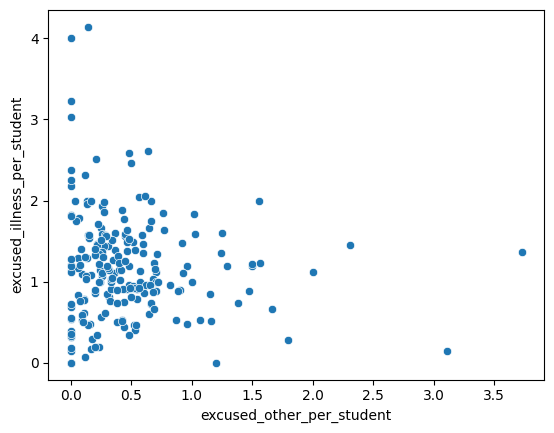

In [36]:
sns.scatterplot(
    data=df_2019_oct,
    x="excused_other_per_student",
    y="excused_illness_per_student",
)

<Axes: xlabel='excused_other_per_student', ylabel='excused_illness_per_student'>

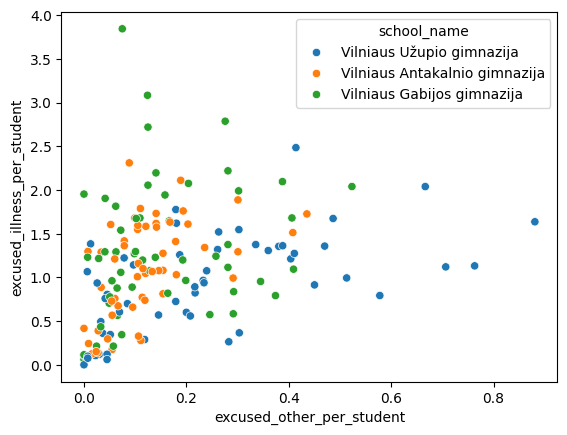

In [37]:
sns.scatterplot(
    data=df_three_schools,
    x="excused_other_per_student",
    y="excused_illness_per_student",
    hue="school_name",
)

## Other nice plots


### Boxplots


<Axes: xlabel='municipality_name', ylabel='total_missed_per_student'>

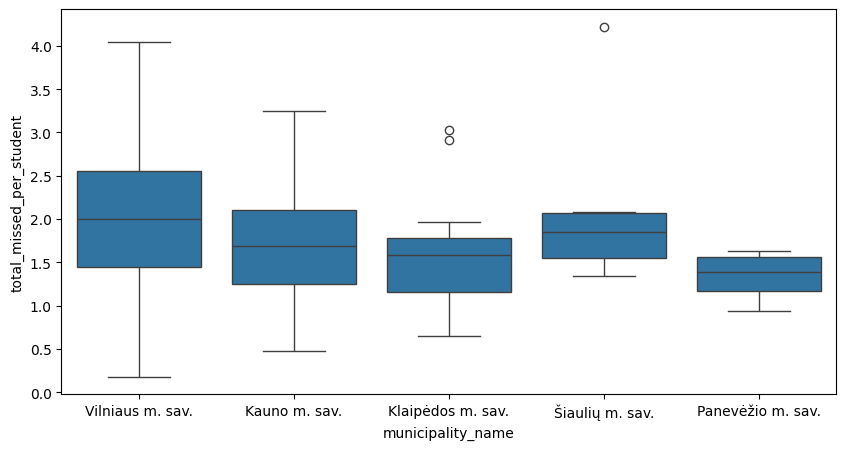

In [38]:
df_2019_oct_cities = df_2019_oct[
    df_2019_oct["municipality_name"].isin(
        [
            "Vilniaus m. sav.",
            "Kauno m. sav.",
            "Klaipėdos m. sav.",
            "Panevėžio m. sav.",
            "Šiaulių m. sav.",
        ]
    )
]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_2019_oct_cities,
    x="municipality_name",
    y="total_missed_per_student",
)

<Axes: xlabel='municipality_name', ylabel='total_missed_per_student'>

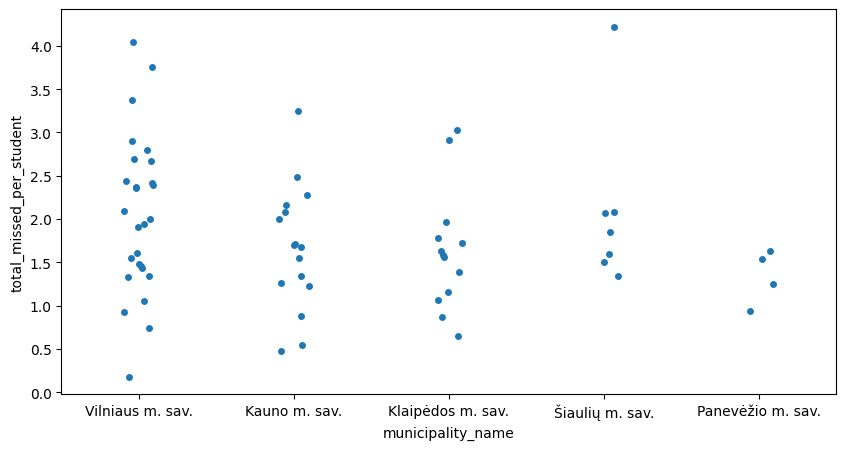

In [39]:
plt.figure(figsize=(10, 5))
sns.stripplot(
    data=df_2019_oct_cities,
    x="municipality_name",
    y="total_missed_per_student",
)

<Axes: xlabel='municipality_name', ylabel='total_missed_per_student'>

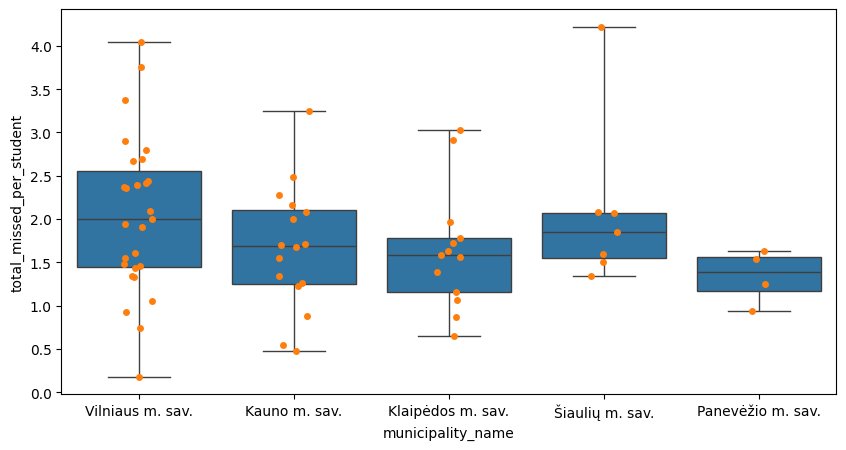

In [40]:
# combine
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_2019_oct_cities,
    x="municipality_name",
    y="total_missed_per_student",
    whis=[0, 100],
)
sns.stripplot(
    data=df_2019_oct_cities,
    x="municipality_name",
    y="total_missed_per_student",
)

### Jointplots



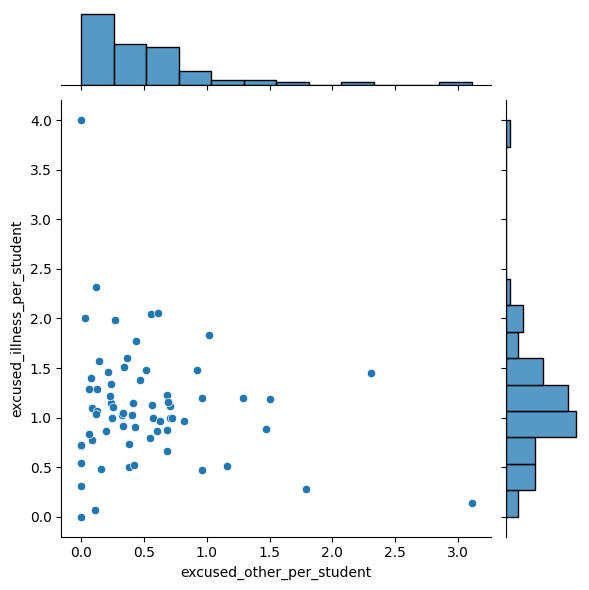

In [41]:
sns.jointplot(
    data=df_2019_oct_cities,
    x="excused_other_per_student",
    y="excused_illness_per_student",
)

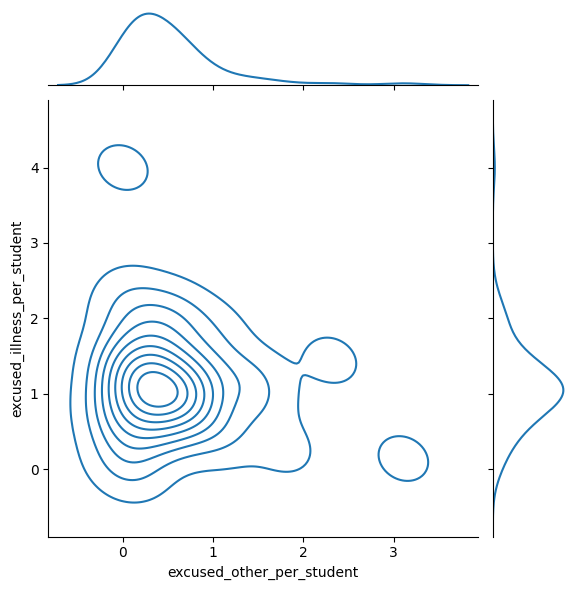

In [42]:
# aka contour plot
sns.jointplot(
    data=df_2019_oct_cities,
    x="excused_other_per_student",
    y="excused_illness_per_student",
    kind="kde",
)

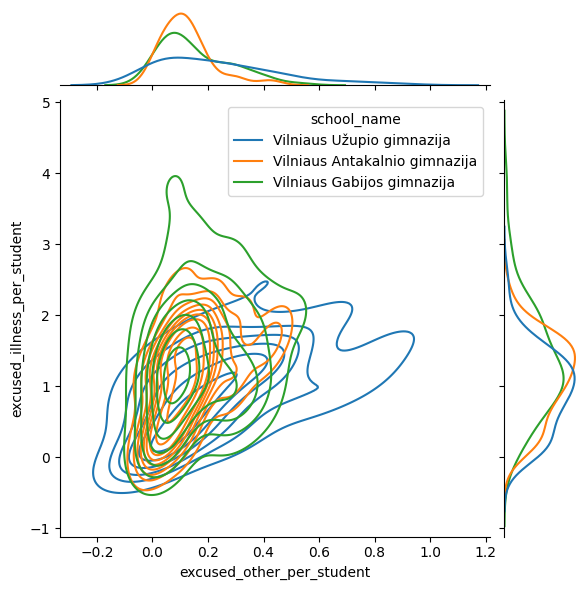

In [43]:
sns.jointplot(
    data=df_three_schools,
    x="excused_other_per_student",
    y="excused_illness_per_student",
    kind="kde",
    hue="school_name",
)

Contrast this plot with the scatter plot we made before on the same dataframe - at least to me the contour plot is easier to look at.


### Lineplot with Confidence Interval


What if we're plotting against time something that has variance? There are several plots for that.


<Axes: xlabel='school_year', ylabel='total_missed_per_student'>

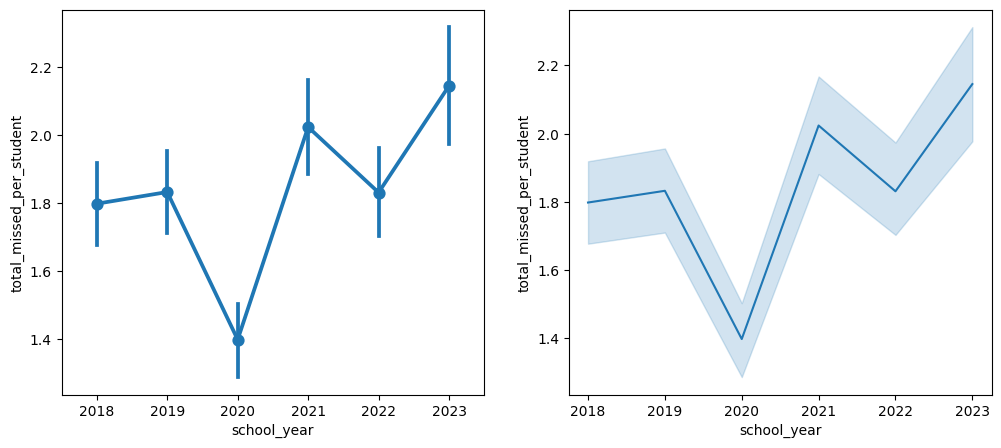

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.pointplot(data=df_oct_all_years, x="school_year", y="total_missed_per_student", ax=axs[0])
sns.lineplot(
    data=df_oct_all_years,
    x="school_year",
    y="total_missed_per_student",
    errorbar="ci",
    ax=axs[1],
)

<Axes: xlabel='school_year', ylabel='total_missed_per_student'>

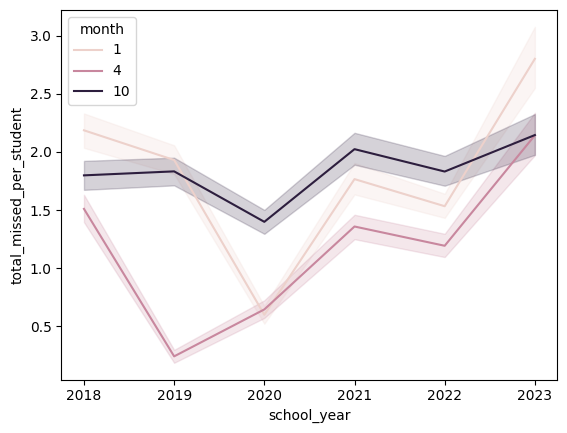

In [45]:
df_oct_jan_apr_all_years = df[df["month"].isin([10, 1, 4])]

sns.lineplot(
    data=df_oct_jan_apr_all_years,
    x="school_year",
    y="total_missed_per_student",
    hue="month",
    errorbar="ci",
)

## Recap

- Use [seaborn plot gallery](https://seaborn.pydata.org/examples/index.html) for inspiration.
- There are only four key plots you need to know:
  - histogram - for plotting the distribution of a single variable
  - lineplot - for plotting how something changes across time
  - scatter plot - for plotting a relationship between two continuous variables
  - barplot - for plotting a relationship between continuous and categorical variables
- The rest of the plots are variations or combinations of these four key plots.
- A data project can be very complex with lots of moving parts. Remember to begin small and build up in complexity over time.


